# House Prices: Advanced Regression Techniques
**EE563, Machine Learning**
- Alper Tunga Güven - 290206012
- Alper Akçakoca - **********


### Contents:
1. **Loading the data**
2. **Exploratory data analysis**
    - 2.1 The target: `SalePrice`
    - 2.2 Missing values
    - 2.3 Which features drive price?
    - 2.4 Categorical drivers
    - 2.5 Skewness of the numeric predictors
    - 2.6 Temporal patterns
    - 2.7 Key continuous features vs price
    - 2.8 Outliers
3. **Outlier removal**
4. **Target transformation**
5. **Missing value handling**
6. **Feature engineering**
7. **Categorical encoding**
8. **Skewness correction**
9. **Model building and cross-validation**
10. **Stacking ensemble**
11. **Generate submission**
12. **Summary**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from scipy.special import boxcox1p
from scipy.optimize import minimize_scalar

from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error
from sklearn.base import clone

from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
RNG = 42
print("Libraries loaded. Random seed:", RNG)

Libraries loaded. Random seed: 42


## 1. Loading the data

In [2]:
train = pd.read_csv("data/train.csv")
test  = pd.read_csv("data/test.csv")
print("train:", train.shape, " test:", test.shape)
train.head()

train: (1460, 81)  test: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# The test set has every column except the target.
print("Columns only in train:", set(train.columns) - set(test.columns))
print("\nDtype mix in train:")
print(train.dtypes.value_counts())

Columns only in train: {'SalePrice'}

Dtype mix in train:
str        43
int64      35
float64     3
Name: count, dtype: int64


## 2. Exploratory data analysis

Let's explore the data before doing any feature engineering or model training to see the distributions of features and how they correlate with the target variable `SalePrice`.

### 2.1 The target: `SalePrice`

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64


Text(0.5, 1.0, 'SalePrice')

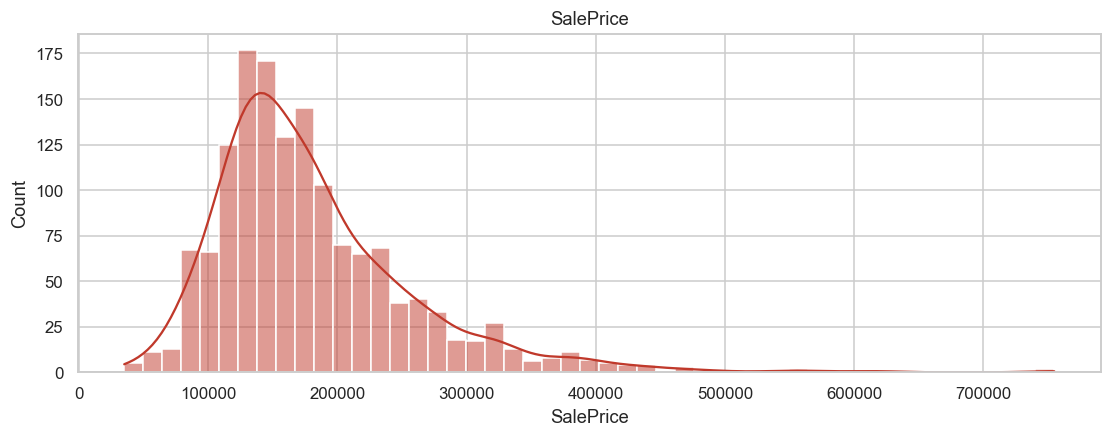

In [4]:
print(train["SalePrice"].describe().round(0))

plt.figure(figsize=(12, 4))
sns.histplot(train["SalePrice"], kde=True, color="#c0392b")
plt.title("SalePrice")


**Observation.** `SalePrice` is strongly **right-skewed**.  This is the result of few
expensive homes stretch the upper tail. Let's apply `log1p` to make the distribution more symmetric. The
competition is also scored on the log of the price which makes sense to use it to transform `SalePrice` feature.

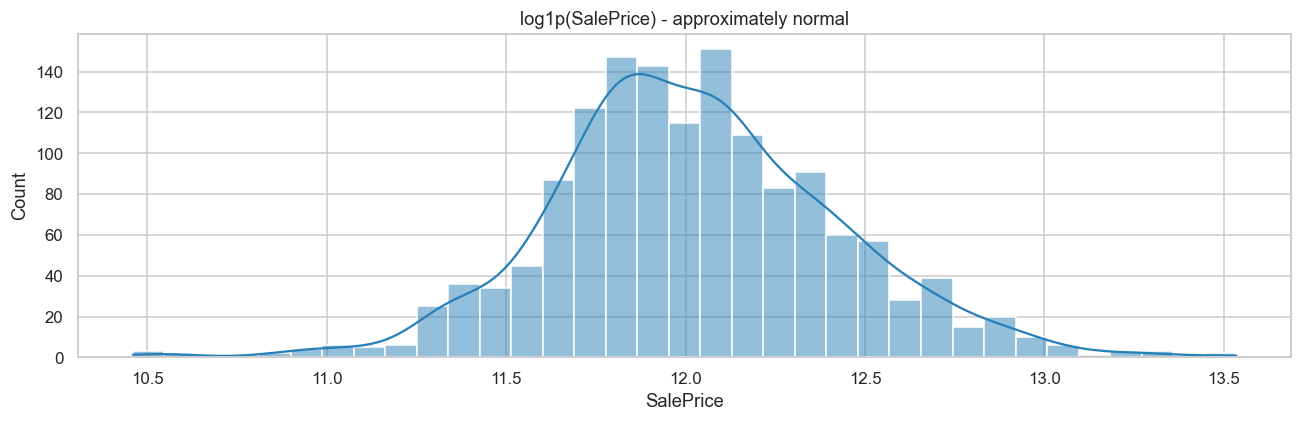


Skewness  raw: 1.881  | log1p: 0.121


In [5]:
plt.figure(figsize=(12, 4))

sns.histplot(np.log1p(train["SalePrice"]), kde=True, color="#2980b9")
plt.title("log1p(SalePrice) - approximately normal")
plt.tight_layout(); plt.show()

print("\nSkewness  raw:", round(skew(train['SalePrice']), 3),
      " | log1p:", round(skew(np.log1p(train['SalePrice'])), 3))

### 2.2 Missing values

19 columns contain NaN in the training set

PoolQC          99.5 %
MiscFeature     96.3 %
Alley           93.8 %
Fence           80.8 %
MasVnrType      59.7 %
FireplaceQu     47.3 %
LotFrontage     17.7 %
GarageType       5.5 %
GarageYrBlt      5.5 %
GarageFinish     5.5 %
GarageQual       5.5 %
GarageCond       5.5 %
BsmtExposure     2.6 %
BsmtFinType2     2.6 %
BsmtQual         2.5 %
BsmtCond         2.5 %
BsmtFinType1     2.5 %
MasVnrArea       0.5 %
Electrical       0.1 %
dtype: str


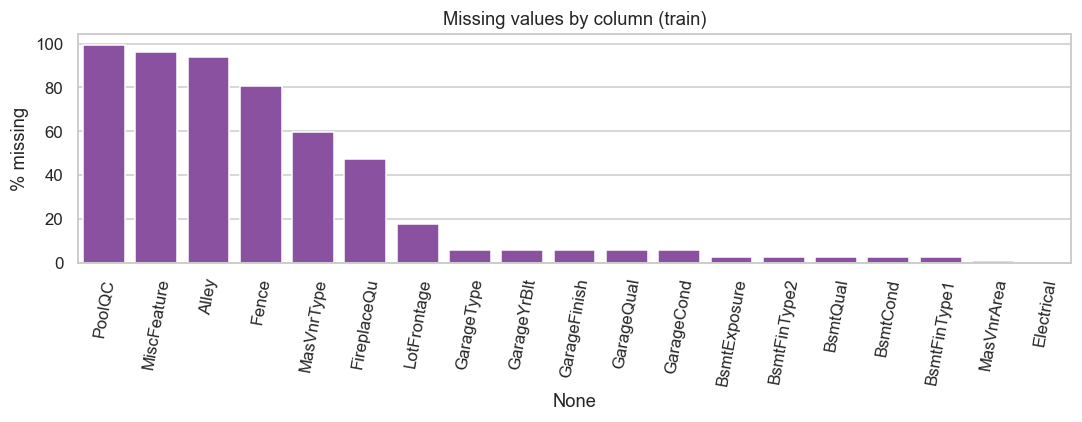

In [6]:
miss = train.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print(f"{len(miss)} columns contain NaN in the training set\n")
print((miss / len(train) * 100).round(1).astype(str) + " %")

plt.figure(figsize=(10, 4))
sns.barplot(x=miss.index, y=miss.values / len(train) * 100, color="#8e44ad")
plt.xticks(rotation=80); plt.ylabel("% missing")
plt.title("Missing values by column (train)")
plt.tight_layout(); plt.show()

19 columns contain `NaN`, led by `PoolQC` (99.5%), `MiscFeature`
(96.3%), `Alley` (93.8%) and `Fence` (80.8%). `NA` encodes the *absence* of a feature (no
pool, no alley, etc.), which `pandas` reads as `NaN`. In feature engineering we must
turn these `NA`s into an explicit `"None"` category (or `0`) rather than dropping and losing that important information.

### 2.3 Which features drive price?

To see which numeric features correlate with the target price, we rank them by Pearson correlation
with `SalePrice` and visualise the strongest ones.

Top correlations with SalePrice:
 OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
GarageYrBlt     0.486
MasVnrArea      0.477
Name: SalePrice, dtype: float64


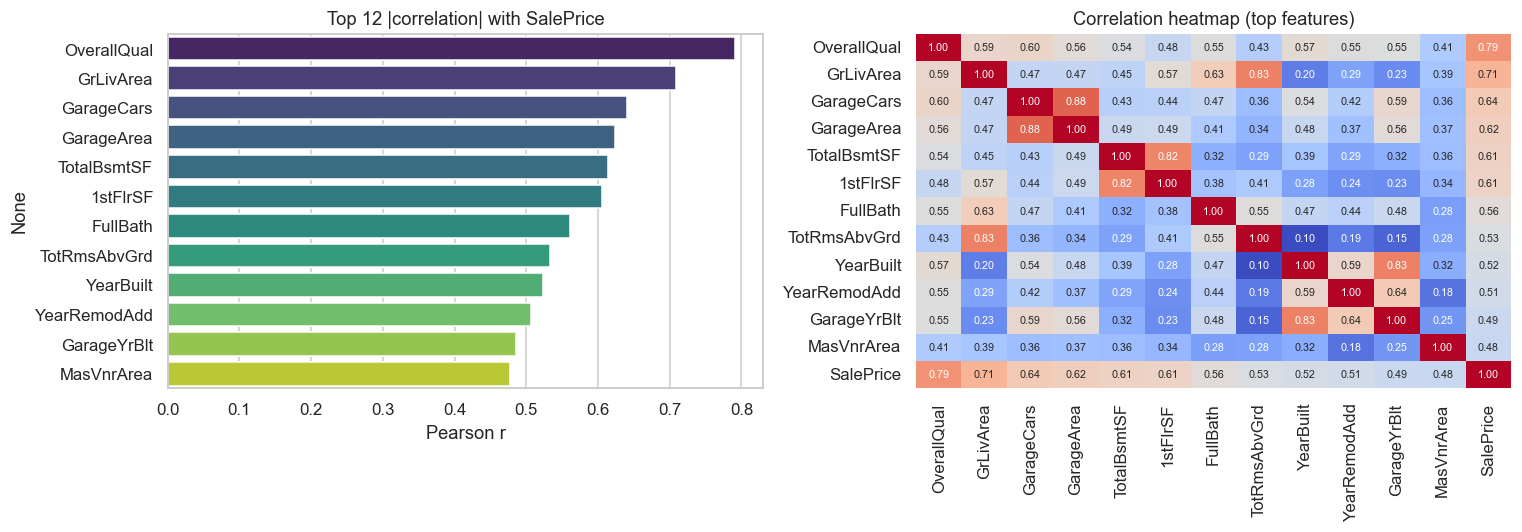

In [7]:
num = train.select_dtypes(include=[np.number])
corr = num.corr(numeric_only=True)["SalePrice"].drop("SalePrice").sort_values(ascending=False)
top = corr.head(12)
print("Top correlations with SalePrice:\n", top.round(3))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=top.values, y=top.index, ax=ax[0], palette="viridis")
ax[0].set_title("Top 12 |correlation| with SalePrice"); ax[0].set_xlabel("Pearson r")

cols = top.index.tolist() + ["SalePrice"]
sns.heatmap(num[cols].corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", ax=ax[1], cbar=False, annot_kws={"size": 7})
ax[1].set_title("Correlation heatmap (top features)")
plt.tight_layout(); plt.show()

**Observation.** `OverallQual` (overall material/finish quality, r = 0.79) and the
living-area measures, namely `GrLivArea` (0.71), `GarageCars`/`GarageArea` (about 0.64) and
`TotalBsmtSF` (0.61), are the strongest linear correlates of price. The heatmap also shows
these predictors are correlated with each othe* (e.g. `GarageCars` vs `GarageArea`),
which motivates the regularised linear models used later. The dominance of size and quality
directly inspires the engineered features `TotalSF` and `OverallScore`.

### 2.4 Categorical drivers

43 features are categorical which were not included in the previous correlation ranking. The most important is `Neighborhood` (location). Below we order each category
by its median `SalePrice` and draw boxplots for three influential categoricals.

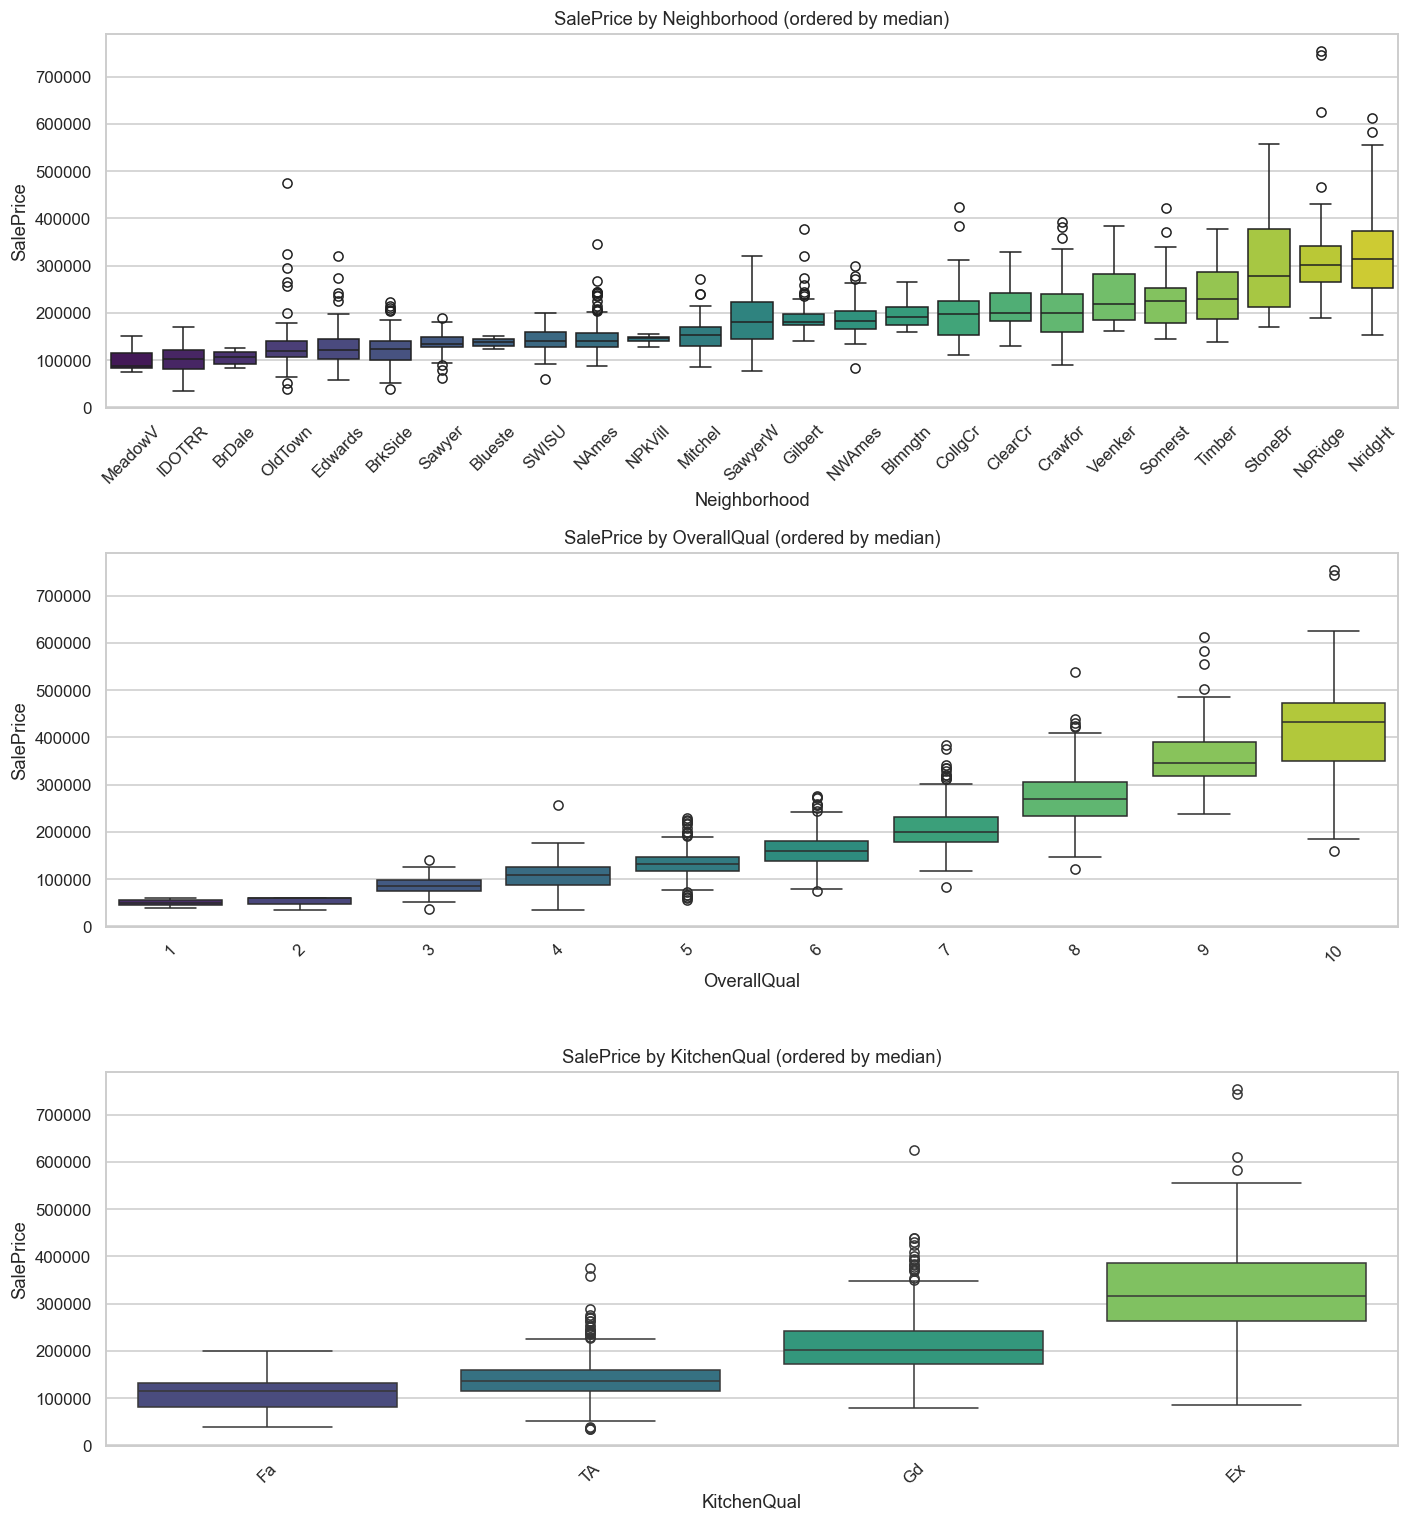

Cheapest : MeadowV   $ 88000
Priciest : NridgHt   $315000
Median-price ratio: 3.6x


In [8]:
d = train[["Neighborhood", "OverallQual", "KitchenQual", "SalePrice"]].copy()
d["OverallQual"] = d["OverallQual"].astype(str)        # treat the 1-10 rating as a category

fig, ax = plt.subplots(3, 1, figsize=(13, 14))
for a, col in zip(ax, ["Neighborhood", "OverallQual", "KitchenQual"]):
    order = d.groupby(col)["SalePrice"].median().sort_values().index
    sns.boxplot(data=d, x=col, y="SalePrice", order=order, ax=a, palette="viridis")
    a.set_title(f"SalePrice by {col} (ordered by median)")
    a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

spread = train.groupby("Neighborhood")["SalePrice"].median().sort_values()
print("Cheapest : %-9s $%6d" % (spread.index[0],  spread.iloc[0]))
print("Priciest : %-9s $%6d" % (spread.index[-1], spread.iloc[-1]))
print("Median-price ratio: %.1fx" % (spread.iloc[-1] / spread.iloc[0]))

**Observation.** Location dominates: median price ranges **3.6x** across neighbourhoods,
from about $88k (MeadowV) up to about $315k (NridgHt). `OverallQual` climbs cleanly and
monotonically, each quality step adding value, and `KitchenQual` behaves the same way
(`Ex` far above `TA`). These strong, ordered effects means we can encode the quality ladders as **ordinal integers**, and **one-hot** nominal categoricals
like `Neighborhood`.

### 2.5 Skewness of the numeric predictors

We log-transformed the target in Section 2.1 but many features are skewed too. Ranking numeric
features by absolute skewness shows which would benefit from a similar transform.

Numeric features with |skew| > 0.75: 21 of 36


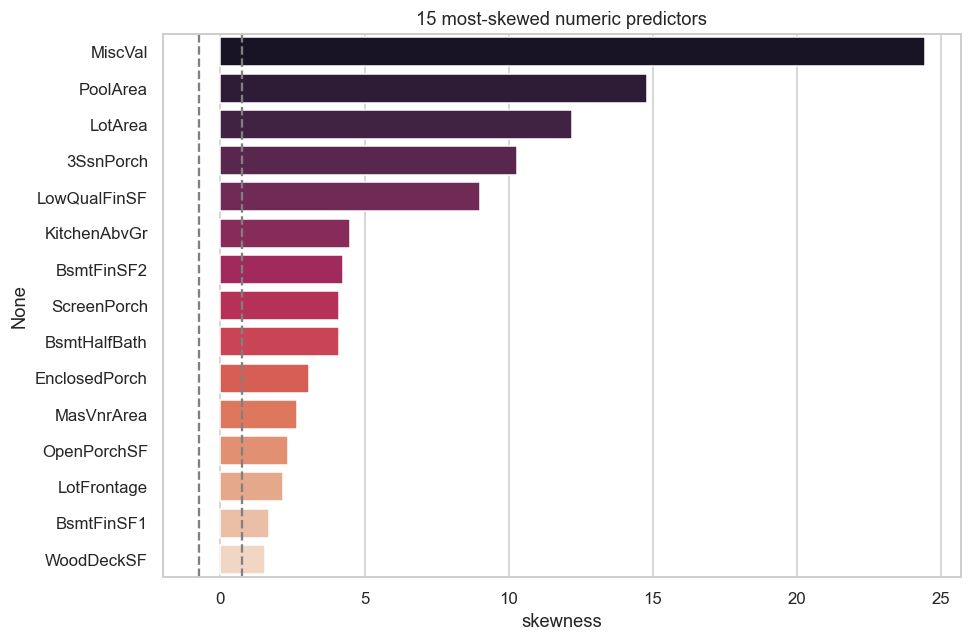

In [9]:
num_feats = train.select_dtypes(include=[np.number]).drop(columns=["Id", "SalePrice"])
skews = num_feats.apply(lambda c: skew(c.dropna())).sort_values(key=np.abs, ascending=False)
print("Numeric features with |skew| > 0.75:", int((skews.abs() > 0.75).sum()), "of", len(skews))

plt.figure(figsize=(9, 6))
top = skews.head(15)
sns.barplot(x=top.values, y=top.index, palette="rocket")
plt.axvline(0.75, color="grey", ls="--"); plt.axvline(-0.75, color="grey", ls="--")
plt.xlabel("skewness"); plt.title("15 most-skewed numeric predictors")
plt.tight_layout(); plt.show()

**Observation.** 21 of 36 numeric predictors exceed |skew| > 0.75, with extreme right
tails in `MiscVal`, `PoolArea`, `LotArea` and the porch areas (mostly zeros with a few
large values). We can improve these features using Box-Cox transform which linearises their relationship with the log-target and lowers RMSE for the linear and kernel models.

### 2.6 Temporal patterns

The homes sold between 2006 and 2010, straddling the U.S. housing crash. We check whether
the sale year, sale month, or construction year carry signal.

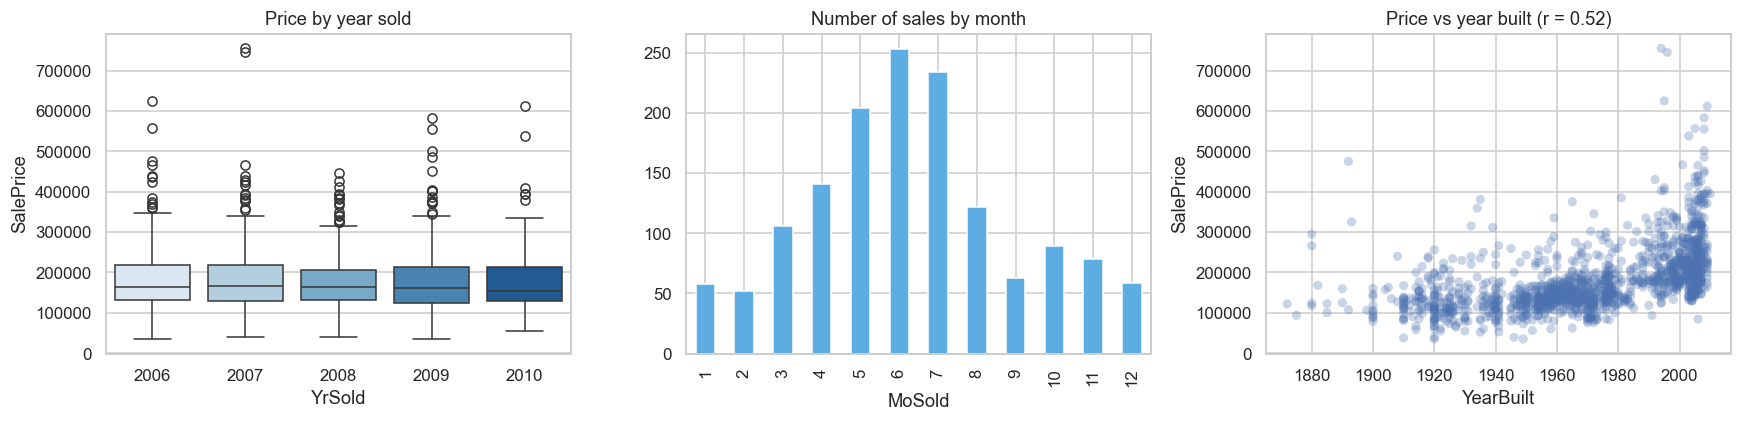

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=train, x="YrSold", y="SalePrice", ax=ax[0], palette="Blues")
ax[0].set_title("Price by year sold")
train.groupby("MoSold").size().plot(kind="bar", ax=ax[1], color="#5dade2")
ax[1].set_title("Number of sales by month"); ax[1].set_xlabel("MoSold")
sns.scatterplot(x=train.YearBuilt, y=train.SalePrice, ax=ax[2], alpha=0.3, edgecolor="none")
ax[2].set_title(f"Price vs year built (r = {train.YearBuilt.corr(train.SalePrice):.2f})")
plt.tight_layout(); plt.show()

**Observation.** `YrSold` barely moves the median price, so it is a weak predictor. Sales are strongly **seasonal**, peaking in May to July. `YearBuilt` correlates 0.52 with price (newer sells for more), which means we can engineer a new feature `Age = YrSold - YearBuilt` instead of feeding raw years to the models.

### 2.7 Key continuous features vs price

Finally we plot the headline size features against the (log) target with a fitted
regression line, to confirm the relationship the models will exploit is roughly linear.

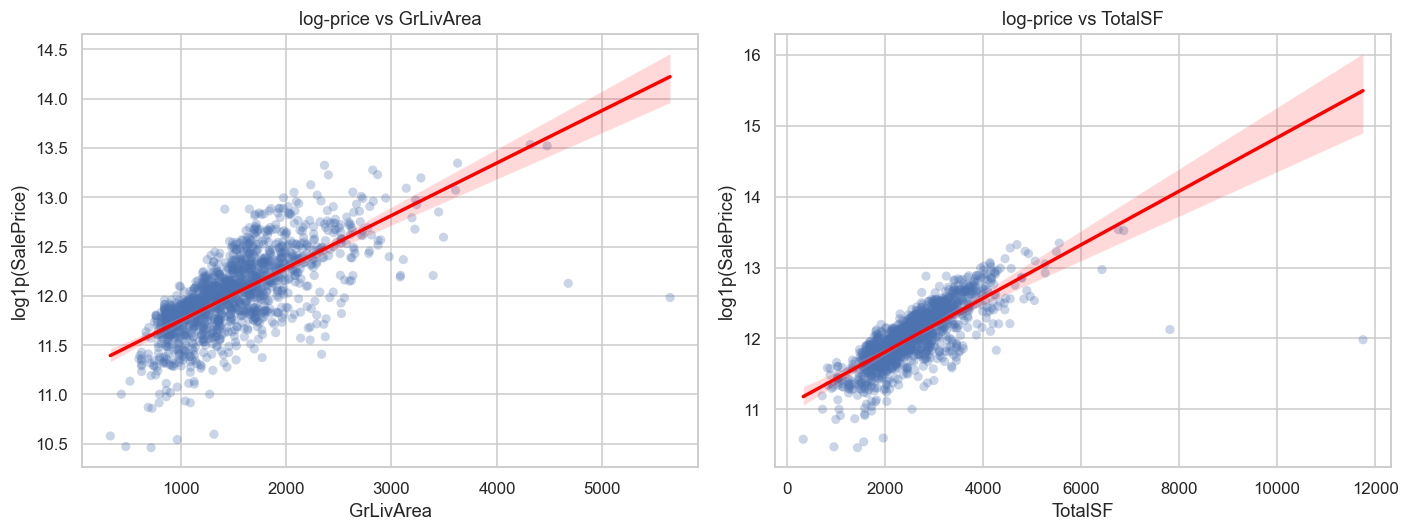

In [11]:
plot_df = train.copy()
plot_df["TotalSF"] = plot_df["TotalBsmtSF"] + plot_df["1stFlrSF"] + plot_df["2ndFlrSF"]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, feat in zip(ax, ["GrLivArea", "TotalSF"]):
    sns.regplot(x=plot_df[feat], y=np.log1p(plot_df["SalePrice"]), ax=a,
                scatter_kws={"alpha": 0.3, "edgecolor": "none"}, line_kws={"color": "red"})
    a.set_ylabel("log1p(SalePrice)"); a.set_title(f"log-price vs {feat}")
plt.tight_layout(); plt.show()

**Observation.** Both `GrLivArea` and the engineered `TotalSF` (basement + both floors)
are strongly and almost **linearly** related to log-price, with `TotalSF` the tighter fit.
This linearity on the log scale confirms that the `log1p(target)` + regularised-linear
strategy is well matched to the data, and motivates `TotalSF` as an engineered feature.

### 2.8 Outliers

To spot anomalous points we plot `SalePrice` against the strongest size-related predictors
from Section 2.3: `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF` and
`OverallQual`. We flag the two homes with `GrLivArea > 4000 sq ft` that sold cheaply and
highlight **those same rows (red)** in every panel, to check whether they look anomalous
across features too, not just in one column.

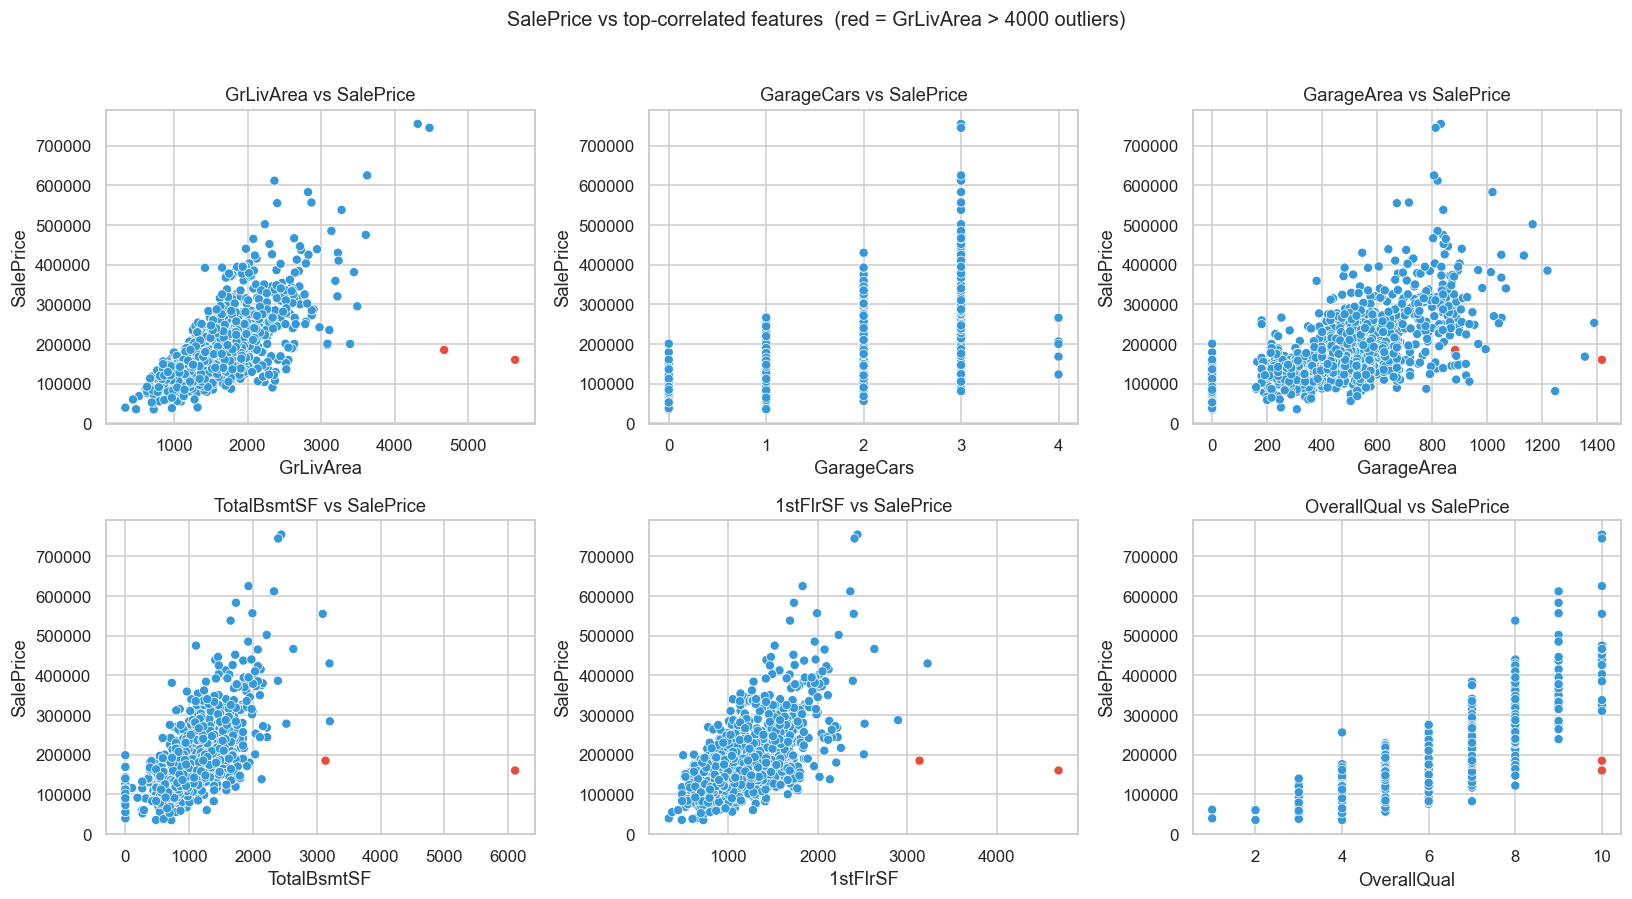

Outliers to remove: 2


In [12]:
features = ["GrLivArea", "GarageCars", "GarageArea",
            "TotalBsmtSF", "1stFlrSF", "OverallQual"]
mask = (train.GrLivArea > 4000) & (train.SalePrice < 300000)   # the two known outliers

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), features):
    sns.scatterplot(x=train[feat], y=train.SalePrice, hue=mask,
                    palette={False: "#3498db", True: "#e74c3c"},
                    legend=False, ax=ax)
    ax.set_title(f"{feat} vs SalePrice")
fig.suptitle("SalePrice vs top-correlated features  (red = GrLivArea > 4000 outliers)",
             y=1.02, fontsize=13)
plt.tight_layout(); plt.show()
print("Outliers to remove:", int(mask.sum()))

**Observation.** The two homes with `GrLivArea > 4000 sq ft` that sold cheaply (red) also
stand out as large-yet-cheap in the correlated features: they sit at the far right of
`GarageArea`, `TotalBsmtSF` and `1stFlrSF` while staying low on price. Appearing anomalous
across several independent measurements confirms they are genuine outliers rather than a
quirk of one column. The dataset's author recommends discarding these abnormal sales as
they would distort the fit, so we must remove these two rows.

## 3. Outlier removal

We remove the two well-known outliers: houses with more than 4000 sq ft of living area that
sold for under $300,000. The dataset's author flags these as anomalous sales that distort
the fit. They are exactly the points highlighted in Section 2.8.

In [13]:
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
print(f"Removing {len(outliers)} outlier(s):")
print(outliers[['Id', 'GrLivArea', 'SalePrice']].to_string(index=False))

train = train.drop(outliers.index).reset_index(drop=True)
print(f"\nTraining set after removal: {train.shape[0]} rows")

Removing 2 outlier(s):
  Id  GrLivArea  SalePrice
 524       4676     184750
1299       5642     160000

Training set after removal: 1458 rows


## 4. Target transformation

We model `log1p(SalePrice)`. This normalises the right-skewed target seen in Section 2.1,
and because the competition is scored on the log of price, minimising RMSE on the log target
is equivalent to minimising the competition's RMSLE.

In [14]:
y_train = np.log1p(train['SalePrice'])
print(f"Target log-transformed. Skewness: {y_train.skew():.4f}, Kurtosis: {y_train.kurt():.4f}")

Target log-transformed. Skewness: 0.1216, Kurtosis: 0.8048


## 5. Missing value handling

Train and test are combined so every column is processed consistently. The missing values
fall into three groups:

1. `NA` means the feature is absent (no pool, alley, basement, and so on): fill with `"None"`.
2. `NA` means a zero quantity (no garage area, no masonry veneer): fill with `0`.
3. Genuinely unknown values (`LotFrontage`, `MSZoning`, and similar): impute with the
   neighborhood median or the column mode.

In [15]:
# Save IDs and combine datasets
train_id = train['Id']
test_id = test['Id']
n_train = train.shape[0]

train.drop(['Id', 'SalePrice'], axis=1, inplace=True)
test.drop('Id', axis=1, inplace=True)

all_data = pd.concat([train, test], axis=0, ignore_index=True)
print(f"Combined dataset: {all_data.shape}")

Combined dataset: (2917, 79)


In [16]:
# Category 1: NA means "None" (feature doesn't exist)
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

# Category 2: NA means 0
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

# Category 3: Truly missing - impute with statistics
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

mode_cols = ['MSZoning', 'Functional', 'Utilities', 'Exterior1st', 'Exterior2nd',
             'Electrical', 'KitchenQual', 'SaleType']
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

remaining = all_data.isnull().sum().sum()
print(f"Remaining missing values: {remaining}")
assert remaining == 0, "Still have missing values!"
print("All missing values handled successfully.")

Remaining missing values: 0
All missing values handled successfully.


## 6. Feature engineering

We add features that capture structure the raw columns hide: size totals (`TotalSF`,
`TotalBathrooms`, `TotalPorchSF`), age and remodel features, presence flags, and the
quality-by-size interactions (`QualGrLivArea`, `QualTotalSF`, and others) that Sections 2.3
and 2.4 suggested would matter most.

In [17]:
# --- Original engineered features ---
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBathrooms'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                               all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])
all_data['TotalPorchSF'] = (all_data['OpenPorchSF'] + all_data['EnclosedPorch'] +
                             all_data['3SsnPorch'] + all_data['ScreenPorch'] +
                             all_data['WoodDeckSF'])
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['RemodAge'] = all_data['YrSold'] - all_data['YearRemodAdd']
all_data['IsRemodeled'] = (all_data['YearRemodAdd'] != all_data['YearBuilt']).astype(int)
all_data['IsNew'] = (all_data['YrSold'] == all_data['YearBuilt']).astype(int)
all_data['HasGarage'] = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt'] = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasPool'] = (all_data['PoolArea'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)
all_data['OverallScore'] = all_data['OverallQual'] * all_data['OverallCond']

# --- Interaction features ---
all_data['QualGrLivArea'] = all_data['OverallQual'] * all_data['GrLivArea']
all_data['QualTotalSF'] = all_data['OverallQual'] * all_data['TotalSF']
all_data['QualTotalBsmtSF'] = all_data['OverallQual'] * all_data['TotalBsmtSF']
all_data['QualGarageArea'] = all_data['OverallQual'] * all_data['GarageArea']
all_data['QualFireplaces'] = all_data['OverallQual'] * all_data['Fireplaces']
all_data['QualBathrooms'] = all_data['OverallQual'] * all_data['TotalBathrooms']
all_data['GarageInteract'] = all_data['GarageCars'] * all_data['GarageArea']

# --- Binary and ratio features ---
all_data['Has2ndFloor'] = (all_data['2ndFlrSF'] > 0).astype(int)
all_data['BsmtFinRatio'] = all_data['BsmtFinSF1'] / (all_data['TotalBsmtSF'] + 1)

print("Feature engineering complete.")
print(f"Total features: {all_data.shape[1]}")

new_feats = ['TotalSF', 'TotalBathrooms', 'QualGrLivArea', 'QualTotalSF',
             'GarageInteract', 'BsmtFinRatio']
for f in new_feats:
    print(f"  {f:20s} - mean: {all_data[f].mean():.2f}")

Feature engineering complete.
Total features: 100
  TotalSF              - mean: 2542.52
  TotalBathrooms       - mean: 2.22
  QualGrLivArea        - mean: 9519.62
  QualTotalSF          - mean: 16211.07
  GarageInteract       - mean: 979.75
  BsmtFinRatio         - mean: 0.39


## 7. Categorical encoding

Quality and condition features have a natural order, so we map them to ordinal integers
(`Ex` > `Gd` > `TA` > `Fa` > `Po`). Nominal features with no order (`Neighborhood`,
`RoofStyle`, and so on) are one-hot encoded. Two near-constant columns (`Street`,
`Utilities`) are dropped, and `MSSubClass` is treated as categorical.

In [18]:
# Ordinal encoding for quality features
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
             'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
for col in qual_cols:
    all_data[col] = all_data[col].map(qual_map).fillna(0).astype(int)

# Other ordinal features
all_data['BsmtExposure'] = all_data['BsmtExposure'].map(
    {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}).fillna(0).astype(int)
all_data['BsmtFinType1'] = all_data['BsmtFinType1'].map(
    {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}).fillna(0).astype(int)
all_data['BsmtFinType2'] = all_data['BsmtFinType2'].map(
    {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}).fillna(0).astype(int)
all_data['GarageFinish'] = all_data['GarageFinish'].map(
    {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}).fillna(0).astype(int)
all_data['Functional'] = all_data['Functional'].map(
    {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8}).fillna(8).astype(int)
all_data['LandSlope'] = all_data['LandSlope'].map(
    {'Sev': 1, 'Mod': 2, 'Gtl': 3}).fillna(3).astype(int)
all_data['LotShape'] = all_data['LotShape'].map(
    {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4}).fillna(4).astype(int)
all_data['PavedDrive'] = all_data['PavedDrive'].map(
    {'N': 0, 'P': 1, 'Y': 2}).fillna(0).astype(int)
all_data['CentralAir'] = all_data['CentralAir'].map({'N': 0, 'Y': 1}).fillna(0).astype(int)
all_data['Fence'] = all_data['Fence'].map(
    {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}).fillna(0).astype(int)

print("Ordinal encoding applied.")

Ordinal encoding applied.


In [19]:
# Drop low-variance features
all_data.drop(['Street', 'Utilities'], axis=1, inplace=True)

# MSSubClass is categorical despite being numeric
all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)

# One-hot encode remaining categorical features
all_data = pd.get_dummies(all_data, drop_first=True)

print(f"Final feature count after encoding: {all_data.shape[1]}")

Final feature count after encoding: 234


## 8. Skewness correction

Section 2.5 showed many predictors are strongly skewed. We apply a Box-Cox transform
(`boxcox1p`, lambda = 0.15) to every continuous feature with |skewness| > 0.75. This pulls
their distributions toward Gaussian and helps the linear and kernel models in particular.

In [20]:
# Identify skewed continuous features
numeric_feats = all_data.select_dtypes(include=[np.number]).columns
continuous_feats = [f for f in numeric_feats if all_data[f].nunique() > 10]

skewed = all_data[continuous_feats].apply(lambda x: skew(x.dropna()))
high_skew = skewed[abs(skewed) > 0.75].sort_values(ascending=False)

print(f"Features with |skewness| > 0.75: {len(high_skew)}")
print(high_skew.head(10))

lam = 0.15
for feat in high_skew.index:
    # boxcox1p requires values > -1; skip features that violate this
    if (all_data[feat] > -1).all():
        all_data[feat] = boxcox1p(all_data[feat], lam)
    else:
        print(f"  Skipping {feat} (has values <= -1, boxcox1p would produce NaN)")

print(f"\nBox-Cox transform (lambda={lam}) applied to skewed features.")

# Fill any remaining NaN with the column median
nan_count = all_data.isnull().sum().sum()
if nan_count > 0:
    print(f"Warning: {nan_count} NaN values found - filling with column median")
    all_data = all_data.fillna(all_data.median())

Features with |skewness| > 0.75: 27
MiscVal          21.939672
PoolArea         17.688664
LotArea          13.109495
LowQualFinSF     12.084539
3SsnPorch        11.372080
BsmtFinSF2        4.144503
EnclosedPorch     4.002344
ScreenPorch       3.945101
MasVnrArea        2.621719
OpenPorchSF       2.529358
dtype: float64

Box-Cox transform (lambda=0.15) applied to skewed features.


## 9. Model building and cross-validation

We train eight diverse base learners on the same 5-fold split and report RMSE on the log
target (equivalent to RMSLE). For efficiency each fold is trained once and reused to collect
both the score and the out-of-fold (OOF) predictions the stack needs later.

- Linear and kernel models on a `RobustScaler`: `Ridge`, `Lasso`, `ElasticNet` (each
  self-tuning its regularisation), `KernelRidge` (polynomial) and `SVR` (RBF).
- Gradient-boosted models: `GradientBoosting` with Huber loss, plus `XGBoost` and
  `LightGBM`, both with early stopping so the number of trees is chosen per fold.

In [21]:
# Split back into train and test
X_train = all_data.iloc[:n_train].copy()
X_test = all_data.iloc[n_train:].copy()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")

# Cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_evaluate(model, X, y, kf):
    """Train the model once per fold; return mean RMSE, std, and the OOF predictions."""
    oof = np.zeros(len(y))
    scores = []
    for train_idx, val_idx in kf.split(X, y):
        m = clone(model)
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = m.predict(X.iloc[val_idx])
        oof[val_idx] = pred
        scores.append(np.sqrt(mean_squared_error(y.iloc[val_idx], pred)))
    return np.mean(scores), np.std(scores), oof

X_train: (1458, 234)
X_test:  (1459, 234)
y_train: (1458,)


In [22]:
# --- Linear and kernel models ---
print("Training linear & kernel models...")
print()

ridge = make_pipeline(RobustScaler(), RidgeCV(alphas=np.logspace(-3, 3, 30)))
ridge_mean, ridge_std, ridge_oof = cv_evaluate(ridge, X_train, y_train, kf)
print(f"  Ridge      - RMSE: {ridge_mean:.5f} (+/- {ridge_std:.5f})")

lasso = make_pipeline(RobustScaler(), LassoCV(alphas=np.logspace(-5, -2, 30),
                                               max_iter=10000, cv=3))
lasso_mean, lasso_std, lasso_oof = cv_evaluate(lasso, X_train, y_train, kf)
print(f"  Lasso      - RMSE: {lasso_mean:.5f} (+/- {lasso_std:.5f})")

elasticnet = make_pipeline(RobustScaler(), ElasticNetCV(
    alphas=np.logspace(-5, -2, 30),
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    max_iter=10000, cv=3))
enet_mean, enet_std, enet_oof = cv_evaluate(elasticnet, X_train, y_train, kf)
print(f"  ElasticNet - RMSE: {enet_mean:.5f} (+/- {enet_std:.5f})")

kr = make_pipeline(RobustScaler(), KernelRidge(alpha=3.0, kernel='polynomial', degree=2, coef0=2.5))
kr_mean, kr_std, kr_oof = cv_evaluate(kr, X_train, y_train, kf)
print(f"  KernelRidge- RMSE: {kr_mean:.5f} (+/- {kr_std:.5f})")

svr = make_pipeline(RobustScaler(), SVR(C=20, epsilon=0.008, gamma=0.0003, kernel='rbf'))
svr_mean, svr_std, svr_oof = cv_evaluate(svr, X_train, y_train, kf)
print(f"  SVR        - RMSE: {svr_mean:.5f} (+/- {svr_std:.5f})")

Training linear & kernel models...

  Ridge      - RMSE: 0.11349 (+/- 0.00822)
  Lasso      - RMSE: 0.11305 (+/- 0.00702)
  ElasticNet - RMSE: 0.11341 (+/- 0.00754)
  KernelRidge- RMSE: 0.12469 (+/- 0.00603)
  SVR        - RMSE: 0.11375 (+/- 0.00961)


In [23]:
# --- Gradient boosting ---
print("Training Gradient Boosting...")

gbr = GradientBoostingRegressor(
    n_estimators=1000, learning_rate=0.1, max_depth=3,
    max_features='sqrt', min_samples_leaf=15, min_samples_split=10,
    loss='huber', random_state=42)

gbr_mean, gbr_std, gbr_oof = cv_evaluate(gbr, X_train, y_train, kf)
print(f"  GBR        - RMSE: {gbr_mean:.5f} (+/- {gbr_std:.5f})")

Training Gradient Boosting...
  GBR        - RMSE: 0.11677 (+/- 0.00883)


In [24]:
# --- CV helper for tree models with early stopping ---
def cv_tree_model(model, X, y, kf, fit_params=None):
    if fit_params is None:
        fit_params = {}
    oof = np.zeros(len(X))
    scores = []
    best_iters = []

    for fold_n, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        m = clone(model)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], **fit_params)

        if hasattr(m, 'best_iteration'):
            best_iters.append(m.best_iteration)
        elif hasattr(m, 'best_iteration_'):
            best_iters.append(m.best_iteration_)

        pred = m.predict(X_val)
        oof[val_idx] = pred
        rmse = np.sqrt(mean_squared_error(y_val, pred))
        scores.append(rmse)
        iter_info = f" (best iter: {best_iters[-1]})" if best_iters else ""
        print(f"    Fold {fold_n+1}: RMSE = {rmse:.5f}{iter_info}")

    avg_iter = int(np.mean(best_iters)) if best_iters else None
    return np.mean(scores), np.std(scores), oof, avg_iter

# --- XGBoost ---
print("Training XGBoost with early stopping...")
xgb_model = XGBRegressor(
    n_estimators=3000, learning_rate=0.01, max_depth=3,
    min_child_weight=3, gamma=0.01, subsample=0.7,
    colsample_bytree=0.6, reg_alpha=0.001, reg_lambda=1.0,
    early_stopping_rounds=50,
    random_state=42, n_jobs=-1, verbosity=0)

xgb_mean, xgb_std, xgb_oof, xgb_best_iter = cv_tree_model(
    xgb_model, X_train, y_train, kf, fit_params={'verbose': False})

print(f"\n  XGBoost    - RMSE: {xgb_mean:.5f} (+/- {xgb_std:.5f}), avg best iter: {xgb_best_iter}")

Training XGBoost with early stopping...
    Fold 1: RMSE = 0.12229 (best iter: 1477)
    Fold 2: RMSE = 0.10697 (best iter: 2949)
    Fold 3: RMSE = 0.12123 (best iter: 2821)
    Fold 4: RMSE = 0.12633 (best iter: 1253)
    Fold 5: RMSE = 0.10509 (best iter: 1435)

  XGBoost    - RMSE: 0.11638 (+/- 0.00864), avg best iter: 1987


In [25]:
# --- LightGBM ---
print("Training LightGBM with early stopping...")
lgbm_model = LGBMRegressor(
    n_estimators=3000, learning_rate=0.01, num_leaves=5,
    max_depth=-1, min_child_samples=5, subsample=0.7,
    colsample_bytree=0.6, reg_alpha=0.001, reg_lambda=0.5,
    min_split_gain=0.01,
    random_state=42, n_jobs=-1, verbose=-1)

lgbm_mean, lgbm_std, lgbm_oof, lgbm_best_iter = cv_tree_model(
    lgbm_model, X_train, y_train, kf,
    fit_params={'callbacks': [lgb.early_stopping(50), lgb.log_evaluation(0)]})

print(f"\n  LightGBM   - RMSE: {lgbm_mean:.5f} (+/- {lgbm_std:.5f}), avg best iter: {lgbm_best_iter}")

Training LightGBM with early stopping...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2163]	valid_0's l2: 0.0154927
    Fold 1: RMSE = 0.12447 (best iter: 2163)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2104]	valid_0's l2: 0.0131612
    Fold 2: RMSE = 0.11472 (best iter: 2104)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2085]	valid_0's l2: 0.0159565
    Fold 3: RMSE = 0.12632 (best iter: 2085)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1033]	valid_0's l2: 0.0172258
    Fold 4: RMSE = 0.13125 (best iter: 1033)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2174]	valid_0's l2: 0.0117127
    Fold 5: RMSE = 0.10823 (best iter: 2174)

  LightGBM   - RMSE: 0.12100 (+/- 0.00834), avg best iter: 1911


MODEL COMPARISON (CV RMSE = RMSLE)
  Lasso        - 0.11305 (+/- 0.00702)
  ElasticNet   - 0.11341 (+/- 0.00754)
  Ridge        - 0.11349 (+/- 0.00822)
  SVR          - 0.11375 (+/- 0.00961)
  XGBoost      - 0.11638 (+/- 0.00864)
  GBR          - 0.11677 (+/- 0.00883)
  LightGBM     - 0.12100 (+/- 0.00834)
  KernelRidge  - 0.12469 (+/- 0.00603)


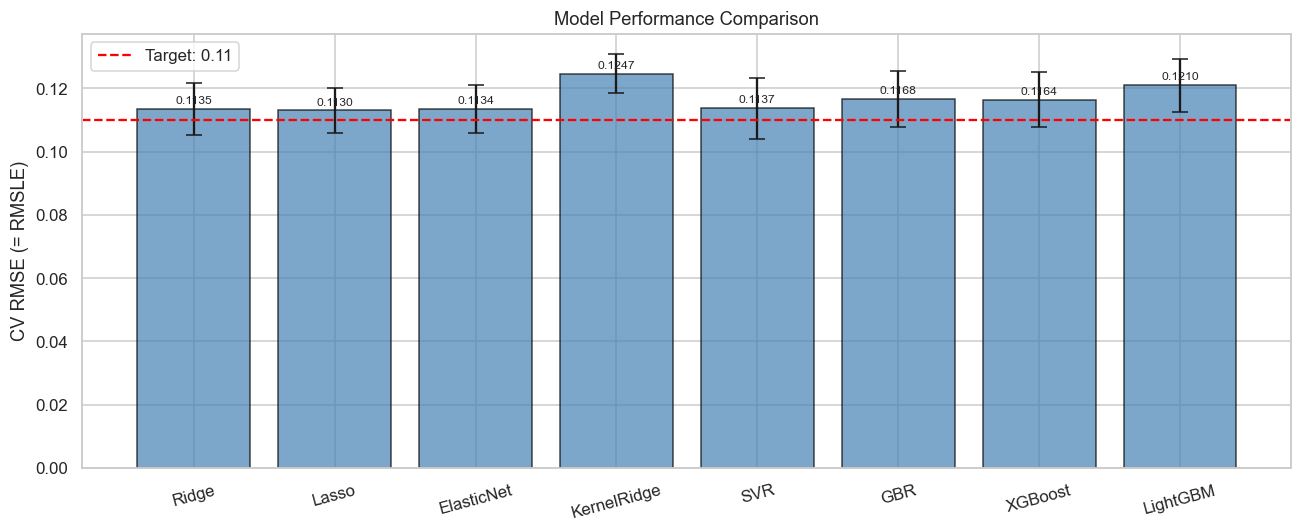

In [26]:
# --- Model Comparison ---
results = {
    'Ridge': (ridge_mean, ridge_std),
    'Lasso': (lasso_mean, lasso_std),
    'ElasticNet': (enet_mean, enet_std),
    'KernelRidge': (kr_mean, kr_std),
    'SVR': (svr_mean, svr_std),
    'GBR': (gbr_mean, gbr_std),
    'XGBoost': (xgb_mean, xgb_std),
    'LightGBM': (lgbm_mean, lgbm_std)
}

print("=" * 50)
print("MODEL COMPARISON (CV RMSE = RMSLE)")
print("=" * 50)
for name, (mean, std) in sorted(results.items(), key=lambda x: x[1][0]):
    print(f"  {name:12s} - {mean:.5f} (+/- {std:.5f})")
print("=" * 50)

fig, ax = plt.subplots(figsize=(12, 5))
names = list(results.keys())
means = [results[n][0] for n in names]
stds = [results[n][1] for n in names]

bars = ax.bar(names, means, yerr=stds, capsize=5, color='steelblue', edgecolor='black', alpha=0.7)
ax.axhline(y=0.11, color='red', linestyle='--', label='Target: 0.11')
ax.set_ylabel('CV RMSE (= RMSLE)')
ax.set_title('Model Performance Comparison')
ax.legend()
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 10. Stacking ensemble

The OOF predictions gathered during cross-validation become the inputs to a `RidgeCV`
meta-learner, which learns the best weighted combination of the base models. We compare this
against a plain equal-weight average, then blend the two and keep the mix that minimises OOF
RMSE. The blend is more robust than either ensemble alone.

In [27]:
# Assemble the OOF matrix from the predictions collected during cross-validation
model_names = ['Ridge', 'Lasso', 'ElasticNet', 'KernelRidge', 'SVR', 'GBR', 'XGBoost', 'LightGBM']
oof_matrix = np.column_stack([ridge_oof, lasso_oof, enet_oof, kr_oof, svr_oof, gbr_oof, xgb_oof, lgbm_oof])
print(f"Stacked OOF matrix: {oof_matrix.shape} (assembled from existing CV - no extra training)")

Stacked OOF matrix: (1458, 8) (assembled from existing CV - no extra training)


In [28]:
# Stacking with a RidgeCV meta-learner
meta_model = RidgeCV(alphas=np.logspace(-4, 4, 200))
stacked_oof = cross_val_predict(meta_model, oof_matrix, y_train, cv=kf)
stacked_rmse = np.sqrt(mean_squared_error(y_train, stacked_oof))
print(f"Stacked Model OOF RMSE:     {stacked_rmse:.5f}")

# Equal-weight average
equal_oof = oof_matrix.mean(axis=1)
equal_rmse = np.sqrt(mean_squared_error(y_train, equal_oof))
print(f"Equal-Weight Avg OOF RMSE:  {equal_rmse:.5f}")

# Find optimal ratio: alpha * stacking + (1 - alpha) * equal_avg
def combined_score(alpha):
    pred = alpha * stacked_oof + (1 - alpha) * equal_oof
    return np.sqrt(mean_squared_error(y_train, pred))

result_alpha = minimize_scalar(combined_score, bounds=(0, 1), method='bounded')
optimal_alpha = result_alpha.x
combined_rmse_val = combined_score(optimal_alpha)

print(f"\nOptimal ratio: {optimal_alpha:.2%} stacking + {1-optimal_alpha:.2%} equal-avg")
print(f"Combined OOF RMSE:          {combined_rmse_val:.5f}")

Stacked Model OOF RMSE:     0.10949
Equal-Weight Avg OOF RMSE:  0.11038

Optimal ratio: 78.64% stacking + 21.36% equal-avg
Combined OOF RMSE:          0.10941


## 11. Generate submission

We refit every base model on the full training set, predict the test set, combine the
predictions with the blend chosen in Section 10, invert the log transform with `expm1`, and
write `submission.csv` in the format Kaggle expects.

In [29]:
# Fit all base models on full training data
print("Fitting base models on full training data...")

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)
elasticnet.fit(X_train, y_train)
kr.fit(X_train, y_train)
svr.fit(X_train, y_train)
gbr.fit(X_train, y_train)

xgb_final = XGBRegressor(
    n_estimators=xgb_best_iter, learning_rate=0.01, max_depth=3,
    min_child_weight=3, gamma=0.01, subsample=0.7,
    colsample_bytree=0.6, reg_alpha=0.001, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbosity=0)
xgb_final.fit(X_train, y_train)

lgbm_final = LGBMRegressor(
    n_estimators=lgbm_best_iter, learning_rate=0.01, num_leaves=5,
    max_depth=-1, min_child_samples=5, subsample=0.7,
    colsample_bytree=0.6, reg_alpha=0.001, reg_lambda=0.5,
    min_split_gain=0.01,
    random_state=42, n_jobs=-1, verbose=-1)
lgbm_final.fit(X_train, y_train)
print("All base models fitted.")

# Generate test predictions from all 8 models
test_preds = np.column_stack([
    ridge.predict(X_test),
    lasso.predict(X_test),
    elasticnet.predict(X_test),
    kr.predict(X_test),
    svr.predict(X_test),
    gbr.predict(X_test),
    xgb_final.predict(X_test),
    lgbm_final.predict(X_test)
])

# Stacking prediction
meta_model.fit(oof_matrix, y_train)
stacked_test = meta_model.predict(test_preds)

# Equal-weight average prediction
equal_test = test_preds.mean(axis=1)

# Final prediction: blend of stacking and equal-weight average
final_pred_log = optimal_alpha * stacked_test + (1 - optimal_alpha) * equal_test
final_pred = np.expm1(final_pred_log)
final_pred = np.maximum(final_pred, 0)

print(f"\nUsing: {optimal_alpha:.2%} stacking + {1-optimal_alpha:.2%} equal-avg")
print(f"\nPrediction statistics:")
print(f"  Mean:   ${final_pred.mean():,.0f}")
print(f"  Median: ${np.median(final_pred):,.0f}")
print(f"  Min:    ${final_pred.min():,.0f}")
print(f"  Max:    ${final_pred.max():,.0f}")

Fitting base models on full training data...
All base models fitted.

Using: 78.64% stacking + 21.36% equal-avg

Prediction statistics:
  Mean:   $178,789
  Median: $157,379
  Min:    $48,658
  Max:    $807,481


In [30]:
# Save submission
submission = pd.DataFrame({'Id': test_id, 'SalePrice': final_pred})
submission.to_csv('submission.csv', index=False)
print("Submission saved to 'submission.csv'")
print(f"Shape: {submission.shape}")
submission.head(10)

Submission saved to 'submission.csv'
Shape: (1459, 2)


,Id,SalePrice
0,1461,117637.716762
1,1462,163800.392759
2,1463,184993.467405
3,1464,194676.980212
4,1465,195537.652235
5,1466,170462.117576
6,1467,178689.115557
7,1468,163995.471460
8,1469,188399.049427
9,1470,121975.702179


## 12. Summary

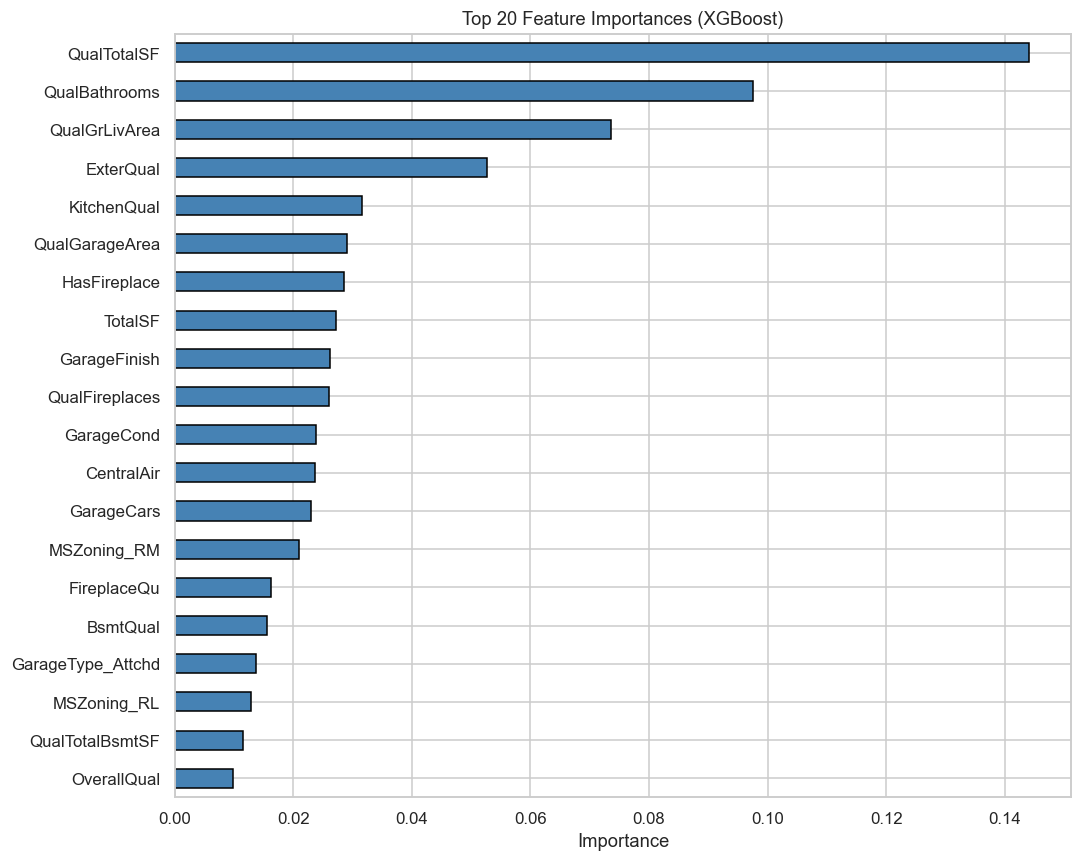

In [31]:
# Feature importance from XGBoost
importance = pd.Series(xgb_final.feature_importances_, index=X_train.columns)
top20 = importance.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.sort_values().plot(kind='barh', color='steelblue', ax=ax, edgecolor='black')
ax.set_title('Top 20 Feature Importances (XGBoost)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [32]:
# Final summary
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"\nIndividual Model CV RMSE (= RMSLE):")
best_single = min(results.items(), key=lambda x: x[1][0])
for name, (mean, std) in sorted(results.items(), key=lambda x: x[1][0]):
    marker = " <-- best single" if name == best_single[0] else ""
    print(f"  {name:12s}: {mean:.5f} (+/- {std:.5f}){marker}")

print(f"\nEnsemble Results:")
print(f"  Stacking (RidgeCV):   {stacked_rmse:.5f}")
print(f"  Equal-Weight Avg:     {equal_rmse:.5f}")
print(f"  Combined ({optimal_alpha:.0%}/{1-optimal_alpha:.0%}):  {combined_rmse_val:.5f}")

target_met = combined_rmse_val < 0.11
status = "ACHIEVED" if target_met else "Close - upload to Kaggle to verify"
print(f"\nTarget RMSLE < 0.11: {status}")
print(f"\nSubmission: submission.csv ({len(submission)} predictions)")
print("=" * 60)

FINAL RESULTS SUMMARY

Individual Model CV RMSE (= RMSLE):
  Lasso       : 0.11305 (+/- 0.00702) <-- best single
  ElasticNet  : 0.11341 (+/- 0.00754)
  Ridge       : 0.11349 (+/- 0.00822)
  SVR         : 0.11375 (+/- 0.00961)
  XGBoost     : 0.11638 (+/- 0.00864)
  GBR         : 0.11677 (+/- 0.00883)
  LightGBM    : 0.12100 (+/- 0.00834)
  KernelRidge : 0.12469 (+/- 0.00603)

Ensemble Results:
  Stacking (RidgeCV):   0.10949
  Equal-Weight Avg:     0.11038
  Combined (79%/21%):  0.10941

Target RMSLE < 0.11: ACHIEVED

Submission: submission.csv (1459 predictions)


### Key takeaways

1. Log-transforming the target was important: it matches the RMSLE metric and normalises the
   distribution for the linear models.
2. Feature engineering (size totals, ages, and quality-by-size interactions) added real
   predictive power beyond the raw columns.
3. `OverallQual` and `TotalSF` were consistently among the most important features.
4. Stacking diverse learners (linear, kernel and tree-based) beat every single model, and
   blending the stack with an equal-weight average added robustness.
5. Careful missing-value handling, separating absent-feature `NA`s from genuinely unknown
   values, prevented information loss.